In [1]:
import sys,copy,os,inspect
if hasattr(sys.modules[__name__], '__file__'):
    _file_name = __file__
else:
    _file_name = inspect.getfile(inspect.currentframe())
CURRENT_FILE_PATH = os.path.dirname(_file_name)
sys.path.append(os.getcwd()+"/../neuronVis")
import matplotlib
import matplotlib.pyplot as plt
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42
matplotlib.use('module://matplotlib_inline.backend_inline')
%matplotlib inline

import IONData 
iondata = IONData.IONData()
import pickle
import Scene,NeuronProcess,SwcLoader
import numpy as np
import Visual as nv
import BoundLaplace,Flatmap

d:\Program Files\anaconda3\envs\neuronVis\lib\site-packages\numpy\_distributor_init.py:30: UserWarning: loaded more than 1 DLL from .libs:
d:\Program Files\anaconda3\envs\neuronVis\lib\site-packages\numpy\.libs\libopenblas.FB5AE2TYXYH2IJRDKGDGQ3XBKLKTF43H.gfortran-win_amd64.dll
d:\Program Files\anaconda3\envs\neuronVis\lib\site-packages\numpy\.libs\libopenblas64__v0.3.21-gcc_10_3_0.dll
  warnings.warn("loaded more than 1 DLL from .libs:"


In [2]:
import IONData 
import FlatNeuron
from skimage import draw, io
grid,dv0,dv1,dv2,flatenPara,depth,outp1,outp2,outp3,inp1,inp2,inp3 = FlatNeuron.getStreamLine()
iondata =IONData.IONData()

# fig,ax = plt.subplots(figsize=(11,7))
    
neurontree = iondata.getNeuronTreeByID('230070','017.swc')

exist  e:\workspace\project\neuron-vis\analyseCase/../neuronVis/../resource/swc/230070/017.swc


In [3]:
outp1.astype(np.int64)
outp2.astype(np.int64)
outp3.astype(np.int64)
outp3.shape

(660, 400, 570)

In [8]:
edges=np.zeros_like(grid)
coordmap=[]
for i in range(outp3.shape[0]):
    print(i)
    if np.sum(grid[i,:,:])==2280000:
        continue
    for j in range(outp3.shape[1]):
        if np.sum(grid[i,j,:])==5700:
            continue
        for k in range(outp3.shape[2]):
            x=int(outp1[i,j,k])
            y=int(outp2[i,j,k])
            z=int(outp3[i,j,k])
            edges[x,y,z]=1
    

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58


KeyboardInterrupt: 

In [7]:
import matplotlib 
%matplotlib inline
import matplotlib.pyplot as plt
edges[0,0,0]=0
edges==1

NameError: name 'edges' is not defined

In [4]:
neurontree = iondata.getNeuronTreeByID('210098','004.swc')
neurontree = iondata.getNeuronTreeByID('221642','477.swc')

img0 = io.imread(r'../resource/flatmapedgebgd.png')
singleimg = img0

# FlatNeuron.flatneuron(neurontree,grid,dv0,dv1,dv2,flatenPara,sum=True,img=singleimg)
FlatNeuron.flatneuron(neurontree,grid,dv0,dv1,dv2,flatenPara,sum=True,img=singleimg,depth0=depth,outp1=outp1,outp2=outp2,outp3=outp3,inp1=inp1,inp2=inp2,inp3=inp3)
io.imsave("../resource/thsample/flatmap/testflatbgd.png",singleimg)

exist  d:\project\python\neuron-vis\figures/../neuronVis/../resource/swc/210098/004.swc
write  d:\project\python\neuron-vis\figures/../neuronVis/../resource/swc/221642/477.swc
0
1
2
3
[709, 460] [703, 436] 30.0
4


D:\project\python\AppData\Local\Temp\ipykernel_37420\765879674.py:9: UserWarning: ../resource/thsample/flatmap/testflatbgd.png is a low contrast image
  io.imsave("../resource/thsample/flatmap/testflatbgd.png",singleimg)


In [4]:
outpx=np.zeros_like(grid)
outpy=np.zeros_like(grid)
outpx= outpx.astype(np.uint16)
outpy= outpy.astype(np.uint16)
import pickle


In [ ]:
from multiprocessing.dummy import Pool as ThreadPool
def process(item):
    # print(item)
    i=item[0]
    j=item[1]
    k=item[2]
    outx = outp1[i,j,k]
    outy = outp2[i,j,k]
    outz = outp3[point[0],point[1],570-point[2]]
    p2d = Flatmap.map2Flatmap(flatenPara,np.array([outx,outy,outz])*2,True)
            # print(p2d)
    if len(p2d)==2:
        outpx[int(i),int(j),int(k)]=p2d[0]
        outpy[int(i),int(j),int(k)]=p2d[1]
    pass
for i in range(2,grid.shape[0]-2):
    print(i)
    if np.sum(grid[i,:,:])==2280000:
        continue
    for j in range(2,grid.shape[1]-2):
        if np.sum(grid[i,j,:])==5700:
            continue
        points = []
        for k in range(2,grid.shape[2]-2):

            point=[i,j,k]
            val = grid[i,j,k]
            if val==10:
                continue
            points.append(point)

        pool = ThreadPool()
        pool.map(process, points)
        pool.close()
        pool.join()

In [18]:
np.sum(grid[0,0,:])
grid.shape

(660, 400, 570)

In [19]:
np.sum(grid[0,0,:])

14250

In [20]:
p2ds={}
for i in range(2,grid.shape[0]-2):
    print(i,np.sum(grid[i,:,:]))
    if np.sum(grid[i,:,:])==5700000:
        continue
    for j in range(2,grid.shape[1]-2):
        
        if np.sum(grid[i,j,:])==14250:
            continue
        for k in range(2,grid.shape[2]-2):

            point=[i,j,k]
            # if point!=[142,196,184]:
            #     continue
            val = grid[i,j,k]
            if val==10:
                continue
            # print(point)
            outx = int(outp1[i,j,k])
            outy = int(outp2[i,j,k])
            outz = int(outp3[point[0],point[1],point[2]])
            p2d=None
            if (outx,outy,outz) not in p2ds.keys():
                # print(outx,outy,outz)
                p2d = Flatmap.map2Flatmap(flatenPara,np.array([outx,outy,outz])*2,True)
                # print(p2d)
                p2ds[(outx,outy,outz)]=p2d
            else:
                p2d=p2ds[(outx,outy,outz)]
            # print(p2d)
            if  p2d is not None  and len(p2d)==2:
                outpx[int(i),int(j),int(k)]=p2d[0]
                outpy[int(i),int(j),int(k)]=p2d[1]
f=open('../resource/outpx.pkl','wb')
pickle.dump(outpx,f)
f.close()
f=open('../resource/outpy.pkl','wb')
pickle.dump(outpy,f)
f.close()

2 5700000
3 5700000
4 5700000
5 5700000
6 5700000
7 5700000
8 5700000
9 5700000
10 5700000
11 5700000
12 5700000
13 5700000
14 5700000
15 5700000
16 5700000
17 5700000
18 5700000
19 5700000
20 5700000
21 5700000
22 5700000
23 5700000
24 5700000
25 5700000
26 5700000
27 5700000
28 5700000
29 5700000
30 5700000
31 5700000
32 5700000
33 5700000
34 5700000
35 5700000
36 5700000
37 5700000
38 5700000
39 5700000
40 5700000
41 5700000
42 5700000
43 5700000
44 5700000
45 5700000
46 5700000
47 5700000
48 5700000
49 5700000
50 5700000
51 5700000
52 5700000
53 5700000
54 5700000
55 5700000
56 5700000
57 5700000
58 5700000
59 5700000
60 5700000
61 5700000
62 5700000
63 5700000
64 5700000
65 5700000
66 5700000
67 5700000
68 5700000
69 5700000
70 5700000
71 5700000
72 5700000
73 5700000
74 5700000
75 5700000
76 5700000
77 5700000
78 5700000
79 5700000
80 5700000
81 5700000
82 5700000
83 5700000
84 5700000
85 5685405
86 5675910
87 5666955
88 5650125
89 5635980
90 5620665
91 5602725
92 5586540
93 5568

In [21]:
import nrrd
nrrd.write('../resource/outpx.nrrd',outpx)
nrrd.write('../resource/outpy.nrrd',outpy)

In [10]:
import pickle
import nrrd
outpx0,header = nrrd.read('../resource/outpx.nrrd')
outpy0,header = nrrd.read('../resource/outpy.nrrd')
with open('../resource/outpx.pkl', 'rb') as f:
    outpx = pickle.load(f)
with open('../resource/outpy.pkl', 'rb') as f:
    outpy = pickle.load(f)

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], dtype=uint16)

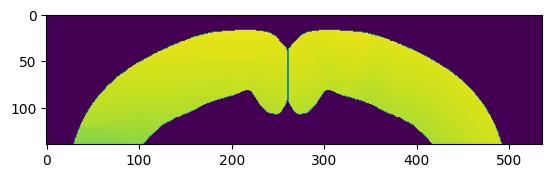

In [14]:
%matplotlib inline
plt.imshow(outpy[291,10:150,24:560])
outpy[291,10:150,24:560]
# outpx[:,:,200]

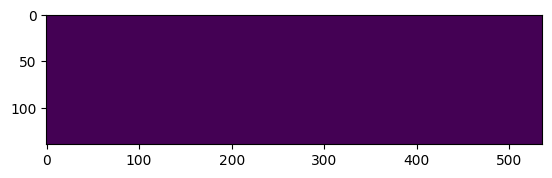

In [15]:
temp = outpy[291,10:150,24:560]-outpy0[291,10:150,24:560]
plt.imshow(temp)

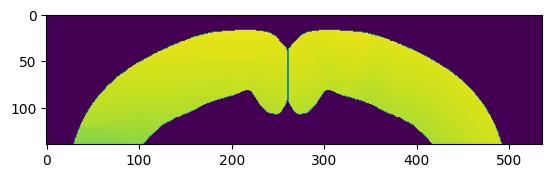

In [12]:
plt.imshow(outpy0[291,10:150,24:560])

In [8]:
import nrrd
iondata = IONData.IONData()
res,depth20path = iondata.getFileFromServer("depth20.nrrd")

depth20,header = nrrd.read(depth20path)

d:\project\python\neuron-vis\figures/../neuronVis/../resource/depth20.nrrd  downloaded


In [3]:
import nrrd
import BoundLaplace

out = np.zeros_like(grid).astype(np.float32)
op = np.zeros((grid.shape[0],grid.shape[1],grid.shape[2],3)).astype(np.float32)
ip = np.zeros_like(op).astype(np.float32)
BoundLaplace.ComputeAllStreamlines(grid,out,op,ip,dv0,dv1,dv2)
nrrd.write('../resource/depthMap.nrrd',out)
nrrd.write('../resource/outPointMap.nrrd',out)
nrrd.write('../resource/inPointMap.nrrd',out)

slice:  0
slice:  1
slice:  2
slice:  3
slice:  4
slice:  5
slice:  6
slice:  7
slice:  8
slice:  9
slice:  10
slice:  11
slice:  12
slice:  13
slice:  14
slice:  15
slice:  16
slice:  17
slice:  18
slice:  19
slice:  20
slice:  21
slice:  22
slice:  23
slice:  24
slice:  25
slice:  26
slice:  27
slice:  28
slice:  29
slice:  30
slice:  31
slice:  32
slice:  33
slice:  34
slice:  35
slice:  36
slice:  37
slice:  38
slice:  39
slice:  40
slice:  41
slice:  42
slice:  43
slice:  44
slice:  45
slice:  46
slice:  47
slice:  48
slice:  49
slice:  50
slice:  51
slice:  52
slice:  53
slice:  54
slice:  55
slice:  56
slice:  57
slice:  58
slice:  59
slice:  60
slice:  61
slice:  62
slice:  63
slice:  64
slice:  65
slice:  66
slice:  67
slice:  68
slice:  69
slice:  70
slice:  71
slice:  72
slice:  73
slice:  74
slice:  75
slice:  76
slice:  77
slice:  78
slice:  79
slice:  80
slice:  81
slice:  82
slice:  83
slice:  84
slice:  85
slice:  86
slice:  87
slice:  88
slice:  89
slice:  90
slice:  9

KeyboardInterrupt: 